Original dimensions: 821 x 643

Scaling Matrix S:
[[1.5 0.  0. ]
 [0.  1.5 0. ]
 [0.  0.  1. ]]

Rotation Matrix R:
[[ 0.9063078  -0.42261827  0.        ]
 [ 0.42261827  0.9063078   0.        ]
 [ 0.          0.          1.        ]]

Translation Matrix T:
[[  1.   0. 100.]
 [  0.   1.  80.]
 [  0.   0.   1.]]

Combined similarity matrix T @ R @ S:
[[  1.3594618  -0.6339274 100.       ]
 [  0.6339274   1.3594618  80.       ]
 [  0.          0.          1.       ]]

New dimensions: 1524 x 1475

Final transformation matrix:
[[  1.3594618  -0.6339274 407.61533  ]
 [  0.6339274   1.3594618  80.       ]
 [  0.          0.          1.       ]]

Saved: task6_fixed_blueprint.jpg


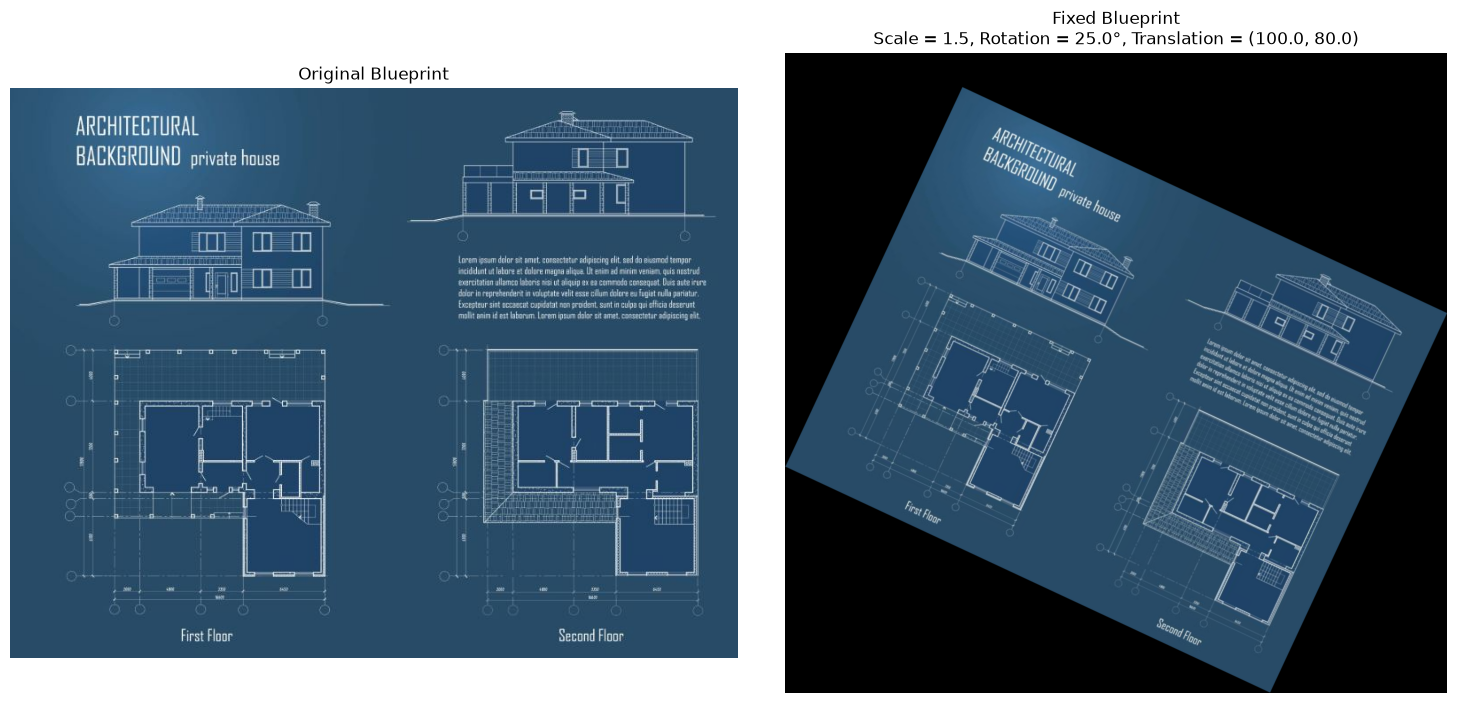

In [1]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Input and output files
# ---------------------------------------------------------
image_path = "blueprint.jpg"
output_path = "task6_fixed_blueprint.jpg"

# ---------------------------------------------------------
# Transformation parameters
# ---------------------------------------------------------
scale = 1.5       # 150% scaling
angle = 25.0      # rotation in degrees
tx = 100.0        # translation in x direction
ty = 80.0         # translation in y direction

# ---------------------------------------------------------
# Read image
# ---------------------------------------------------------
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Could not find image: {image_path}")

h, w = img.shape[:2]

print("Original dimensions:", w, "x", h)

# ---------------------------------------------------------
# Convert angle to radians
# ---------------------------------------------------------
theta = math.radians(angle)

c = math.cos(theta)
s = math.sin(theta)

# ---------------------------------------------------------
# 3x3 Scaling Matrix
#
# S = [ scale    0       0 ]
#     [   0    scale     0 ]
#     [   0      0       1 ]
# ---------------------------------------------------------
S = np.array([
    [scale, 0.0, 0.0],
    [0.0, scale, 0.0],
    [0.0, 0.0, 1.0]
], dtype=np.float32)

print("\nScaling Matrix S:")
print(S)

# ---------------------------------------------------------
# 3x3 Rotation Matrix
#
# R = [ cos(theta)  -sin(theta)  0 ]
#     [ sin(theta)   cos(theta)  0 ]
#     [     0            0       1 ]
# ---------------------------------------------------------
R = np.array([
    [c, -s, 0.0],
    [s,  c, 0.0],
    [0.0, 0.0, 1.0]
], dtype=np.float32)

print("\nRotation Matrix R:")
print(R)

# ---------------------------------------------------------
# 3x3 Translation Matrix
#
# T = [ 1  0  tx ]
#     [ 0  1  ty ]
#     [ 0  0   1 ]
# ---------------------------------------------------------
T = np.array([
    [1.0, 0.0, tx],
    [0.0, 1.0, ty],
    [0.0, 0.0, 1.0]
], dtype=np.float32)

print("\nTranslation Matrix T:")
print(T)

# ---------------------------------------------------------
# Combined Similarity Transformation
#
# M = T @ R @ S
#
# Order:
# 1. Scale
# 2. Rotate
# 3. Translate
# ---------------------------------------------------------
M = T @ R @ S

print("\nCombined similarity matrix T @ R @ S:")
print(M)

# ---------------------------------------------------------
# Calculate transformed corner coordinates
# ---------------------------------------------------------
corners = np.array([
    [0, 0, 1],
    [w, 0, 1],
    [0, h, 1],
    [w, h, 1]
], dtype=np.float32).T

transformed_corners = M @ corners

x_coords = transformed_corners[0, :]
y_coords = transformed_corners[1, :]

min_x = np.min(x_coords)
max_x = np.max(x_coords)

min_y = np.min(y_coords)
max_y = np.max(y_coords)

# ---------------------------------------------------------
# Shift the image if any coordinates are negative
# ---------------------------------------------------------
shift_x = -min_x if min_x < 0 else 0
shift_y = -min_y if min_y < 0 else 0

M[0, 2] += shift_x
M[1, 2] += shift_y

# ---------------------------------------------------------
# New canvas size
# ---------------------------------------------------------
out_w = int(math.ceil(max_x + shift_x))
out_h = int(math.ceil(max_y + shift_y))

print("\nNew dimensions:", out_w, "x", out_h)

print("\nFinal transformation matrix:")
print(M)

# ---------------------------------------------------------
# Apply transformation
# ---------------------------------------------------------
result = cv2.warpPerspective(
    img,
    M,
    (out_w, out_h)
)

# ---------------------------------------------------------
# Save result
# ---------------------------------------------------------
cv2.imwrite(output_path, result)

print("\nSaved:", output_path)

# ---------------------------------------------------------
# Convert BGR to RGB for Matplotlib
# ---------------------------------------------------------
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# ---------------------------------------------------------
# Display original and transformed blueprint in Jupyter
# ---------------------------------------------------------
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Blueprint")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title(
    f"Fixed Blueprint\n"
    f"Scale = {scale}, Rotation = {angle}°, "
    f"Translation = ({tx}, {ty})"
)
plt.axis("off")

plt.tight_layout()
plt.show()
